In [59]:
import h5py
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

with h5py.File("alldata_new.hdf5", "r") as f:
    dat = {k: f[k][:] for k in f.keys()}

import scipy.spatial

nsamples = dat["trap_centers"].shape[0]
N = dat["trap_centers"].shape[1]
dat["rij"] = np.zeros((nsamples, N, N))
dat["rx_ij"] = np.zeros((nsamples, N, N))
dat["ry_ij"] = np.zeros((nsamples, N, N))
dat["dV_ij"] = np.zeros((nsamples, N, N))

for i, r in enumerate(dat["trap_centers"]):
    dat["rij"][i, :, :] = scipy.spatial.distance_matrix(r, r)
    rx = r[:, [0]]
    ry = r[:, [1]]
    dat["rx_ij"][i, :, :] = rx - rx.T
    dat["ry_ij"][i, :, :] = ry - ry.T
    v = dat["V_offset"][i, :][:, None]
    dat["dV_ij"][i, :, :] = v - v.T

import sys
import os

module_path = os.path.abspath(os.path.join("../../src/"))
if module_path not in sys.path:
    sys.path.append(module_path)

from HubbardTweezer.Hubbard.lattice import sqr_lattice

# Pick n.n. distances
nodes, links, node_idx_pair = sqr_lattice(np.array([4, 4]))
nnr = dat["rij"][:, links[:, 0], links[:, 1]]
nnt = dat["t_ij"][:, links[:, 0], links[:, 1]]

# Filter bad samples
# mask = dat["wf_cost"] < 6e-5
mask = np.min(dat["U_i"], axis=1) > 0.8
nmask = np.sum(mask)
nmask

1190

In [60]:
id = np.argmax(dat["wf_cost"][mask])
idx = dat['dir'][mask][id]
print(idx)

2250


In [17]:
dat["V_offset"][mask][id]

array([0.99922505, 1.00676949, 1.01845251, 1.00758361, 0.99428966,
       1.01013215, 0.99898872, 1.01270399, 1.00193057, 0.98131489,
       1.01182943, 0.99992557, 0.99109042, 0.99732735, 1.0158073 ,
       1.01844029])

In [18]:
dat["wf_cost"][mask][id]

0.05560268791537637

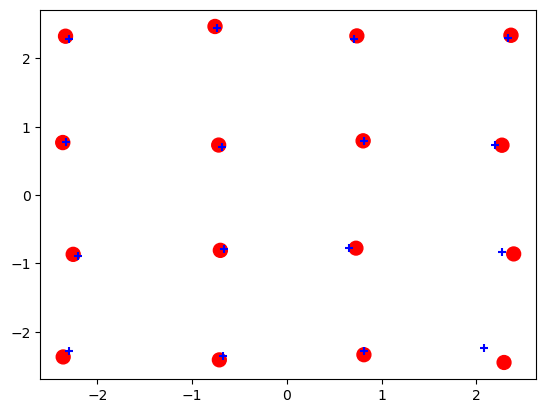

In [19]:
plt.scatter(
    dat["trap_centers"][mask][id, :, 0],
    dat["trap_centers"][mask][id, :, 1],
    c="r",
    s=dat["V_offset"][mask][id] * 100,
    marker="o",
)
plt.scatter(
    dat["wf_centers"][mask][id, :, 0],
    dat["wf_centers"][mask][id, :, 1],
    c="b",
    marker="+",
)

In [33]:
path = "/Users/nottforestfc/Library/CloudStorage/OneDrive-RiceUniversity/Documents/Research/Hubbard Tweezer Parameters/output/LinearRegression/samples_new/"
filename = path + f"3D_4x4_square_None_neq_{id}.ini"

keys = [
"V_offset",
"trap_centers"
]
dat = {k: [] for k in keys}

import reportIO as rep

report = rep.get_report(filename)

V_offset = rep.a(report, "Trap_Adjustments", "V_offset")
trap_centers = rep.a(report, "Trap_Adjustments", "trap_centers")

from HubbardTweezer.Hubbard.equalizer import *
import numpy as np
from HubbardTweezer.Hubbard.io import *

N = 20
L = 4
Ly = 4
d = 3
shape = "square"
w = None
eqt = "neq"
R0 = np.array([3, 3, 7.2])
G = HubbardEqualizer(
    N,
    R0=R0,
    lattice_params=(np.array([L, Ly], dtype=int),(1550, 1600)),
    trap=(52.26, 1000),
    ascatt=1770,
    laser=780,
    band=1,
    dim=d,
    sparse=True,
    shape=shape,
    waist=w,
    equalize=False,
    eqtarget=eqt,
    lattice_symmetry=True,
    symmetry=True,
    verbosity=3,
)
E, W, parity = G.eigen_basis()
A, U, V = G.singleband_Hubbard(eig_sol=[E, W, parity])

Wannier: Number of integration grid set to 257.
DVR: dx=[0.15 0.15 0.36]w is set.
DVR: n=[20 20 20] is set.
DVR: R0=[3.  3.  7.2]w is set.
['x' 'y' 'z']-reflection symmetry is used.
param_set: trap parameter V0=52.26kHz w=1000nm
Lattice: lattice shape is square; lattice constants set to: (1550, 1600)
Lattice: lattice shape is square
Lattice: Full lattice sizes: [4 4]
Lattice: lattice constants: [1.55 1.6 ]w
Lattice: dx fixed to: [0.15 0.15 0.36]w
DVR: dx=[0.15 0.15 0.36]w is set.
DVR: n=[35 36 20] is set.
DVR: R0=[5.325 5.4   7.2  ]w is set.
Equalize: scale_factor is not a number. Set to None.
Illegal x0 provided. Use no initial guess.
Equalize: initial guess:  [ 1.     1.     1.     1.    -2.325 -2.4   -2.325 -0.8   -0.775 -2.4
 -0.775 -0.8  ]

Equalize: Initial trap depths: [1. 1. 1. 1.]
Equalize: Initial trap centers:
[[-2.325 -2.4  ]
 [-2.325 -0.8  ]
 [-0.775 -2.4  ]
 [-0.775 -0.8  ]]
Lattice: Full lattice sizes updated to: [4 4 1]
Lattice: lattice constants updated to: [1.55 1.6  

/Users/nottforestfc/miniforge3/envs/torch/lib/python3.11/site-packages/pymanopt/optimizers/conjugate_gradient.py:67: RuntimeWarning: invalid value encountered in divide
  manifold.inner_product(newx, Pnewgrad, diff)


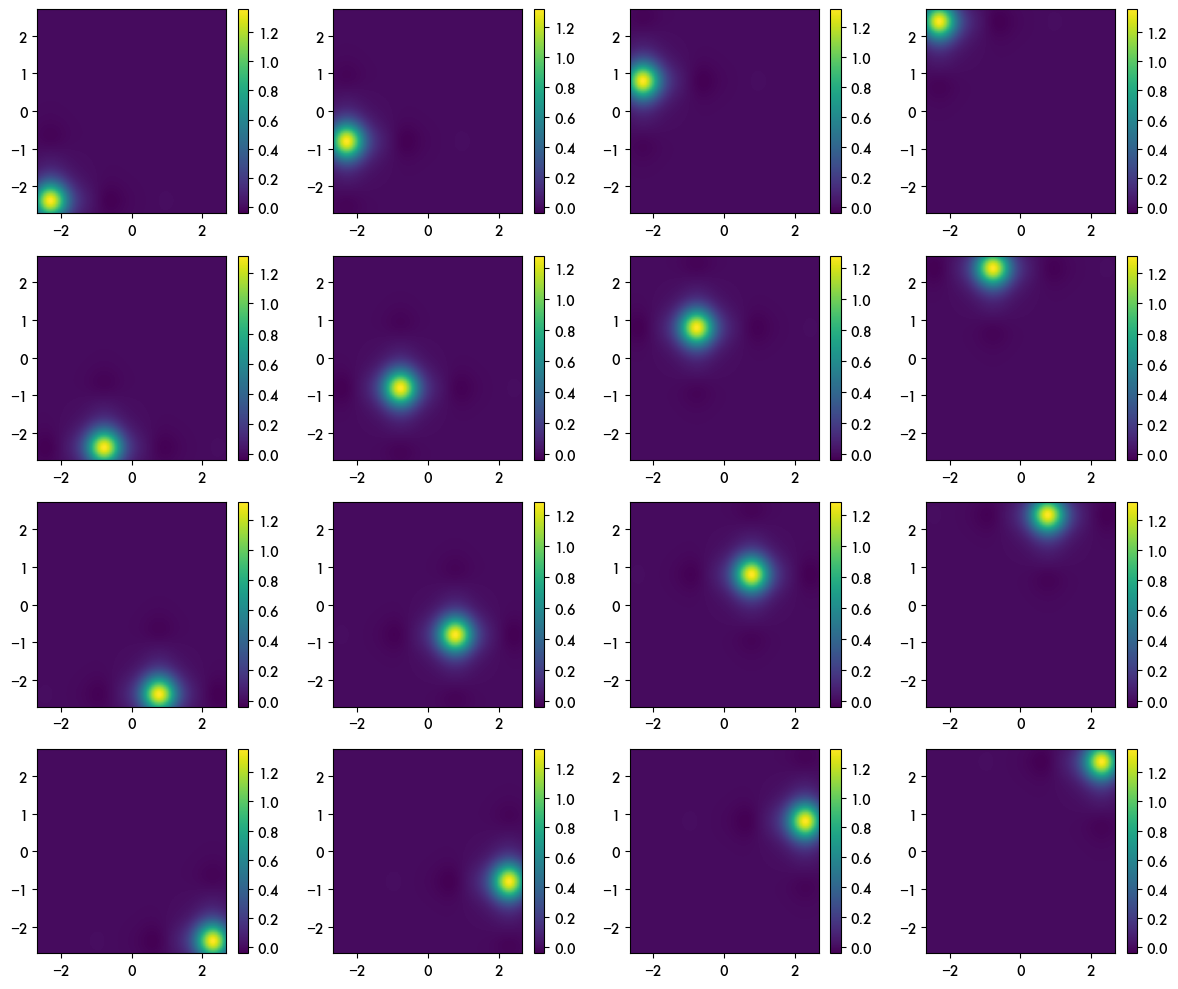

In [37]:
import matplotlib.colors as colors
from HubbardTweezer.tools.fix_phase import fix_phase
import matplotlib.pyplot as plt

x = np.linspace(-G.R0[0] / 2, G.R0[0] / 2, 500)
y = np.linspace(-G.R0[1] / 2, G.R0[1] / 2, 500)
z = np.array([0])
wx = wannier_func((x, y, z), V, G, W[0], parity[0])
X = np.meshgrid(x, y, indexing='ij')

n_rows = L
n_cols = Ly

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 10))

for i in range(G.ghost.Nsite):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]

    Wx = fix_phase(wx[..., 0, i], mode='svmd')  # Assuming fix_phase is a function you've defined

    im = ax.pcolormesh(*X, Wx)
    plt.colorbar(im, ax=ax)

plt.tight_layout()

In [79]:
id = np.argmin(dat["wf_cost"][~mask])
idx = dat['dir'][~mask][id]
print(idx)

1464


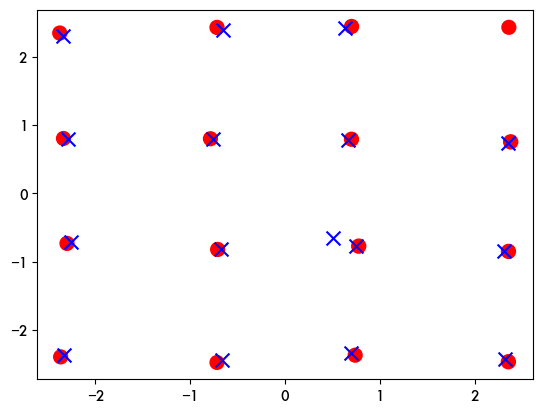

In [71]:
plt.scatter(
    dat["trap_centers"][~mask][id, :, 0],
    dat["trap_centers"][~mask][id, :, 1],
    c="r",
    s=dat["V_offset"][~mask][id] * 100,
    marker="o",
)
plt.scatter(
    dat["wf_centers"][~mask][id, :, 0],
    dat["wf_centers"][~mask][id, :, 1],
    s=100,
    c="b",
    marker="x",
)

In [80]:
import reportIO as rep

path = "/Users/nottforestfc/Library/CloudStorage/OneDrive-RiceUniversity/Documents/Research/Hubbard Tweezer Parameters/output/LinearRegression/samples_new/"
filename = path + f"3D_4x4_square_None_neq_{idx}.ini"
report = rep.get_report(filename)

V_offset = rep.a(report, "Trap_Adjustments", "V_offset")
trap_centers = rep.a(report, "Trap_Adjustments", "trap_centers")

from HubbardTweezer.Hubbard.equalizer import *
import numpy as np
from HubbardTweezer.Hubbard.io import *

N = 20
L = 4
Ly = 4
d = 3
shape = "square"
w = None
eqt = "neq"
R0 = np.array([3, 3, 7.2])
G = HubbardEqualizer(
    N,
    R0=R0,
    lattice_params=(np.array([L, Ly], dtype=int),(1550, 1600)),
    trap=(52.26, 1000),
    ascatt=1770,
    laser=780,
    band=1,
    dim=d,
    sparse=True,
    shape=shape,
    waist=w,
    equalize=False,
    eqtarget=eqt,
    x0=np.concatenate((V_offset, trap_centers.flatten())),
    lattice_symmetry=False,
    verbosity=3,
)
E, W, parity = G.eigen_basis()
A, U, V = G.singleband_Hubbard(eig_sol=[E, W, parity])

Wannier: Number of integration grid set to 257.
DVR: dx=[0.15 0.15 0.36]w is set.
DVR: n=[20 20 20] is set.
DVR: R0=[3.  3.  7.2]w is set.
['x' 'y' 'z']-reflection symmetry is used.
param_set: trap parameter V0=52.26kHz w=1000nm
Lattice: lattice shape is square; lattice constants set to: (1550, 1600)
Lattice: lattice shape is square
Lattice: Full lattice sizes: [4 4]
Lattice: lattice constants: [1.55 1.6 ]w
Lattice: dx fixed to: [0.15 0.15 0.36]w
DVR: dx=[0.15 0.15 0.36]w is set.
DVR: n=[35 36 20] is set.
DVR: R0=[5.325 5.4   7.2  ]w is set.
Equalize: scale_factor is not a number. Set to None.
Equalize: external initial guess is passed.
Equalize: initial guess:  [ 0.99541485  0.99404967  0.98335491  1.00418733  0.98010361  0.99971118
  0.98695744  1.0038401   0.98786108  1.01373065  0.99812712  1.002048
  1.01123794  1.00756525  1.0197228   0.98420956 -2.36661791 -2.39254379
 -2.29986496 -0.73235975 -2.33707607  0.8029201  -2.37604238  2.34438467
 -0.71771037 -2.474274   -0.71048392 -0

/Users/nottforestfc/miniforge3/envs/torch/lib/python3.11/site-packages/pymanopt/optimizers/conjugate_gradient.py:67: RuntimeWarning: invalid value encountered in divide
  manifold.inner_product(newx, Pnewgrad, diff)


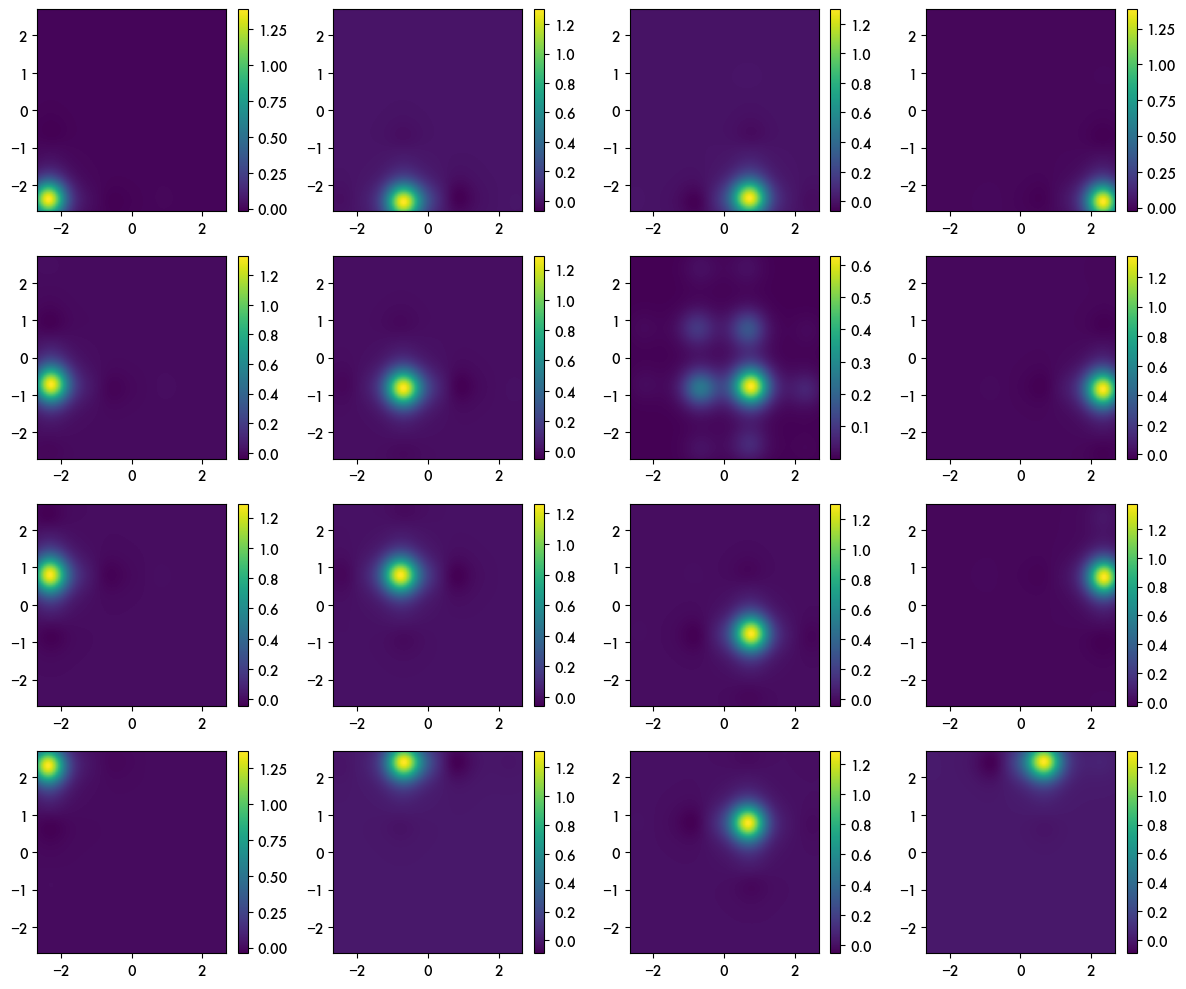

In [81]:
import matplotlib.colors as colors
from HubbardTweezer.tools.fix_phase import fix_phase
import matplotlib.pyplot as plt

x = np.linspace(-G.R0[0] / 2, G.R0[0] / 2, 500)
y = np.linspace(-G.R0[1] / 2, G.R0[1] / 2, 500)
z = np.array([0])
wx = wannier_func((x, y, z), V, G, W[0], parity[0])
X = np.meshgrid(x, y, indexing='ij')

n_rows = L
n_cols = Ly

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 10))

for i in range(G.ghost.Nsite):
    row = i % n_cols
    col = i // n_cols
    ax = axes[row, col]

    Wx = fix_phase(wx[..., 0, i], mode='svmd')  # Assuming fix_phase is a function you've defined

    im = ax.pcolormesh(*X, Wx)
    plt.colorbar(im, ax=ax)

plt.tight_layout()

Because of orthogonality the anomalous WF is more non-local than successful Wannierizated ones.